In [ ]:
import pandas as pd
from sqlalchemy import create_engine
CountryMetaData=pd.read_csv("IDS_CountryMetaData.csv" ,encoding="latin1")
IDS_ALLCountries_Data=pd.read_csv("IDS_ALLCountries_Data.csv" ,encoding="latin1")
IDS_ALLCountries_Data

In [ ]:
IDS_ALLCountries_Data.columns

In [ ]:
IDS_ALLCountries_Data.drop(['2025', '2026', '2027', '2028',
       '2029', '2030', '2031', '2032'],axis=1,inplace=True)

In [ ]:
IDS_ALLCountries_Data.isnull().sum()

In [ ]:
IDS_ALLCountries_Data[IDS_ALLCountries_Data['Series Code'].isnull()]

In [ ]:
IDS_ALLCountries_Data.dropna(subset=['Series Name'], inplace=True)

In [ ]:
import sys
print(sys.executable)

In [ ]:
df_melted = pd.melt(
    IDS_ALLCountries_Data,
    id_vars=[
        'Country Name',
        'Country Code',
        'Counterpart-Area Name',
        'Counterpart-Area Code',
        'Series Name',
        'Series Code'
    ],
    var_name='Year',
    value_name='Value'
)

df_melted.head(100)

In [ ]:
df_melted[df_melted['Value'].isnull()]

In [ ]:
df_melted['Value']=df_melted.groupby('Year')['Value'].transform(lambda x:x.fillna(x.median())) 
# here to replace the null values to median

In [ ]:
df_melted[df_melted['Value'].notna()].head(1000)

In [ ]:
df_melted['Country Name'].nunique()

In [ ]:
df_melted[
    (df_melted['Year'] == '2000') &
    (df_melted['Value'].notna())
]

In [ ]:
df_melted['Series Code'].nunique()   #576

In [ ]:
df_melted['Country Name'].nunique()  #134

In [ ]:
df_melted.to_csv('all_country_metadata.csv',index=False)

In [ ]:
import pandas as pd
series_mdata=pd.read_csv("IDS_SeriesMetaData.csv",encoding="latin1")
series_mdata.head(100)

In [ ]:
series_mdata.isnull().sum()

In [ ]:
series_mdata.drop(['Limitations and exceptions','License Type','General comments'],axis=1,inplace=True) 

# these 3 cols are fully null values

In [ ]:
series_mdata.info()

In [ ]:
series_mdata[series_mdata['Short definition'].isnull()]
series_mdata['Short definition']=series_mdata['Short definition'].ffill()
series_mdata['Dataset']=series_mdata['Dataset'].bfill()

#series_mdata[series_mdata['Short definition'].notna()]
#series_mdata.drop('General comments',axis=1,inplace=True)

In [ ]:
series_mdata.isnull().sum()

In [ ]:
series_mdata[series_mdata['Short definition']].isnull()

In [ ]:
import pandas as pd
food_mdata=pd.read_csv("IDS_FootNoteMetaData.csv",encoding="latin1")
food_mdata.head(100)

In [ ]:
food_mdata.isnull().sum()

In [ ]:
import pandas as pd
coun_mdata=pd.read_csv("IDS_CountryMetaData.csv",encoding="latin1")
coun_mdata.head(100)

In [ ]:
coun_mdata.isnull().sum()

In [ ]:
coun_mdata.columns

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
all_country_metadata=pd.read_csv('all_country_metadata.csv')

In [ ]:
coun_mdata['Region'].isnull().sum() # 14 cols

In [ ]:
coun_mdata[coun_mdata['Region'].isnull()] #here 5 cpls only have data other cols are null val, so here can i drop the rows

In [ ]:
coun_mdata.drop('Region',axis=1,inplace=True) # here i drop the region col

In [ ]:
coun_mdata.groupby('Code')['Region'].value_counts()

In [ ]:
coun_mdata['Income Group'].value_counts() #Here i decided to fill the 'upper middle income' (i take mode)


In [ ]:
coun_mdata['Income Group']=coun_mdata['Income Group'].fillna("upper middle income")  #Here i decided to fill the 'upper middle income'

In [ ]:
coun_mdata['Income Group'].value_counts()
coun_mdata['Income Group'].isnull().sum()

In [ ]:
coun_mdata['Code'].duplicated().sum()

In [ ]:
coun_mdata.drop('Lending category',axis=1,inplace=True) #(droped the col)

In [ ]:
coun_mdata

In [ ]:
coun_mdata[coun_mdata['Lending category'].isnull()] # here same  as it is region column(5 cols only have a data)
coun_mdata['Lending category'].value_counts()
coun_mdata.groupby('Lending category')['Other groups'].value_counts()

In [ ]:
coun_mdata['Other groups']=coun_mdata['Other groups'].fillna("HIPC")

In [ ]:
coun_mdata[coun_mdata['Other groups'].isnull()]

In [ ]:
coun_mdata['Currency Unit'].isnull().sum() #14

In [ ]:
coun_mdata.drop('Currency Unit',axis=1,inplace=True) #(droped the col)

In [ ]:
 #
coun_mdata[coun_mdata['Currency Unit'].isnull()] # most row values are null values so can i drop 

In [ ]:
# here i fill the mode value
coun_mdata['Latest population census']=coun_mdata['Latest population census'].fillna(coun_mdata['Latest population census'].mode()[0])

In [ ]:
coun_mdata.groupby('Code')['Currency Unit'].value_counts()

In [ ]:
coun_mdata[coun_mdata['Latest population census'].notna()]

In [ ]:
coun_mdata['Special Notes'] # here drop the col bcz 50% of the datas are null values
coun_mdata.drop('Special Notes',axis=1,inplace=True)

In [ ]:
coun_mdata['National accounts base year'] # here need to remove the that 14 cols only
coun_mdata['National accounts base year'].notnull().sum()

In [ ]:
coun_mdata['National accounts reference year']=coun_mdata['National accounts reference year'].ffill() 
# here i filled  the value with forword fill


In [ ]:
coun_mdata['PPP survey years']=coun_mdata['PPP survey years'].bfill()
# here i used bfill method to fill the null values

In [ ]:
coun_mdata[coun_mdata['System of trade'].isnull()]
coun_mdata[coun_mdata['System of trade'].notnull()]
coun_mdata['System of trade']=coun_mdata['System of trade'].ffill() # here i fill the null value into forward fill method


In [ ]:
coun_mdata[coun_mdata['Government Accounting concept'].notnull()]
coun_mdata['Government Accounting concept']=coun_mdata['Government Accounting concept'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['Government Accounting concept'].isnull().sum()

In [ ]:
coun_mdata['IMF data dissemination standard']=coun_mdata['IMF data dissemination standard'].bfill()
# Here i filled the null value using bfill method

In [ ]:
coun_mdata['IMF data dissemination standard'].isnull().sum()

In [ ]:
coun_mdata[coun_mdata['IMF data dissemination standard'].notnull()]

In [ ]:
coun_mdata['Latest agricultural census'].notnull().sum() # 60 rows are null value so drop the the col is fine (drop)

In [ ]:
coun_mdata.drop('Latest agricultural census',axis=1,inplace=True) # drop the column

In [ ]:
coun_mdata['Latest industrial data'].isnull().sum()

In [ ]:
coun_mdata['Latest industrial data']=coun_mdata['Latest industrial data'].bfill() # here i use to fill the value or remove the col also .null values are 49

In [ ]:
coun_mdata['Vital registration complete']=coun_mdata['Vital registration complete'].bfill()
# Here i filled the null value using bfill method

In [ ]:
coun_mdata['Latest water withdrawal data'].isnull().sum()

In [ ]:

coun_mdata['Latest water withdrawal data']=coun_mdata['Latest water withdrawal data'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['Latest water withdrawal data'].isnull().sum()

In [ ]:
coun_mdata['2-alpha code'].isnull().sum()

In [ ]:
coun_mdata['WB-2 code'].isnull().sum()

In [ ]:
coun_mdata['Table Name'].isnull().sum()

In [ ]:
coun_mdata['Short Name'].isnull().sum()

In [ ]:
coun_mdata['Balance of Payments Manual in use']=(coun_mdata['Balance of Payments Manual in use'].fillna(coun_mdata['Balance of Payments Manual in use'].mode()[0]))
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['Balance of Payments Manual in use'].isnull().sum()

In [ ]:
coun_mdata['Latest household survey']

pd.set_option('display.max_columns',None)
coun_mdata

In [ ]:
coun_mdata['Latest household survey']=coun_mdata['Latest household survey'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['National accounts base year']=coun_mdata['National accounts base year'].bfill()
coun_mdata
# Here i filled the null value using bfill method

In [ ]:
coun_mdata[coun_mdata['National accounts reference year'].isnull()]
coun_mdata[coun_mdata['National accounts reference year'].notnull()]


In [ ]:
coun_mdata['System of National Account']=coun_mdata['System of National Account'].bfill()
# Here i filled the null value using bfill method

In [ ]:
coun_mdata['National accounts reference year']=coun_mdata['National accounts reference year'].fillna(coun_mdata['National accounts reference year'].mode()[0])
# Here i filled the null value using mode method

In [ ]:
coun_mdata['System of National Accounts']=coun_mdata['System of National Accounts'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['SNA price valuation']=coun_mdata['SNA price valuation'].bfill()
# Here i filled the null value using bfill method

In [ ]:
coun_mdata['External debt Reporting status']=coun_mdata['External debt Reporting status'].bfill()
# Here i filled the null value using bfill method

In [ ]:
coun_mdata['Source of most recent Income and expenditure data']=coun_mdata['Source of most recent Income and expenditure data'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['Vital registration complete']=coun_mdata['Vital registration complete'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['Vital registration complete']=coun_mdata['Vital registration complete'].bfill()

In [ ]:
coun_mdata['Latest industrial data']=coun_mdata['Latest industrial data'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata['Latest trade data']=coun_mdata['Latest trade data'].ffill()
# Here i filled the null value using ffill method

In [ ]:
coun_mdata.to_csv('country_metedata.csv',index=False)

# After the cleaning part is here

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [ ]:
import pandas as pd
country_mdata=pd.read_csv('country_metedata.csv')
country_mdata.isnull().sum()

In [ ]:
country_mdata.head()

In [ ]:
foot_metadata=pd.read_csv('foot_metadata.csv')
foot_metadata.isnull().sum()

In [ ]:
foot_metadata['Country Code'].value_counts()

In [ ]:
foot_metadata.info()

In [ ]:
series_metadata=pd.read_csv('series_metadata.csv')
series_metadata.isnull().sum()

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
all_country_metadata=pd.read_csv('all_country_metadata.csv')

In [2]:
all_country_metadata

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,9.046966e+06
1,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,9.046966e+06
2,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,9.046966e+06
3,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.DPPG,2000,9.046966e+06
4,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.OFFT,2000,9.046966e+06
...,...,...,...,...,...,...,...,...
1574445,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, official creditors ...",DT.UND.OFFT.CD,2024,6.881084e+08
1574446,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, private creditors (...",DT.UND.PRVT.CD,2024,6.350490e+06
1574447,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, total (UND, current...",DT.UND.DPPG.CD,2024,6.944589e+08
1574448,Zimbabwe,ZWE,World,WLD,"Use of IMF credit (DOD, current US$)",DT.DOD.DIMF.US.CD,2024,0.000000e+00


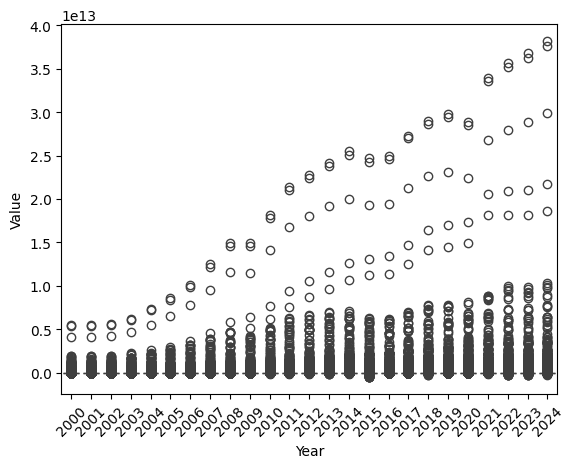

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
all_country_metadata=pd.read_csv('all_country_metadata.csv')
sns.boxplot(data=all_country_metadata, x="Year", y="Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
all_country_metadata['Series Code'].value_counts() #574-series code unique

In [4]:
all_country_metadata['Value'].mean()

np.float64(7823951293.217532)

In [5]:
all_country_metadata['Value'].median()

np.float64(20973714.35)

In [6]:
all_country_metadata['Value'].mode()

0    0.0
Name: Value, dtype: float64

In [ ]:
all_country_metadata.describe()

In [ ]:
plt.figure(figsize=(12, 6))

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Year', y='Value', data=all_country_metadata)
plt.xlabel('Year')
plt.ylabel('Value')
plt.xticks(fontsize=12)  
plt.xticks(rotation=45) # X-axis values
plt.yticks(fontsize=12) 
plt.show()

In [ ]:
country_sum=all_country_metadata.groupby('Country Name')['Value'].sum()

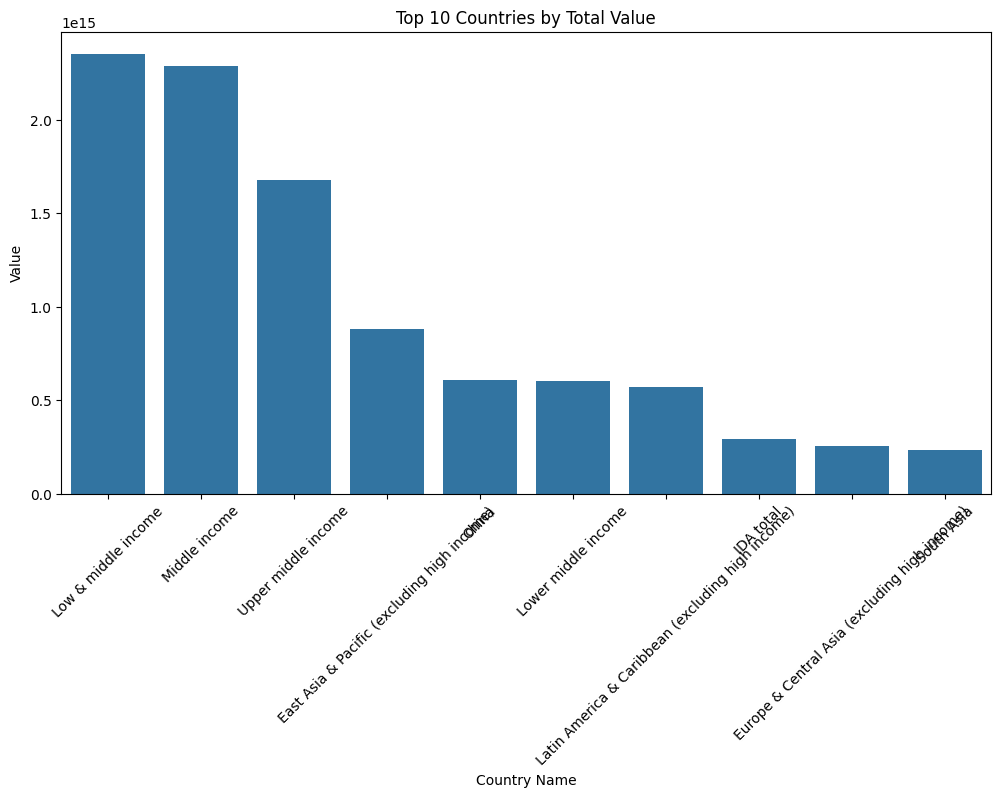

In [10]:
country_sum = (
    all_country_metadata
    .groupby('Country Name', as_index=False)['Value']
    .sum()
    .sort_values('Value', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=country_sum,
    x='Country Name',
    y='Value'
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Total Value")

plt.show()

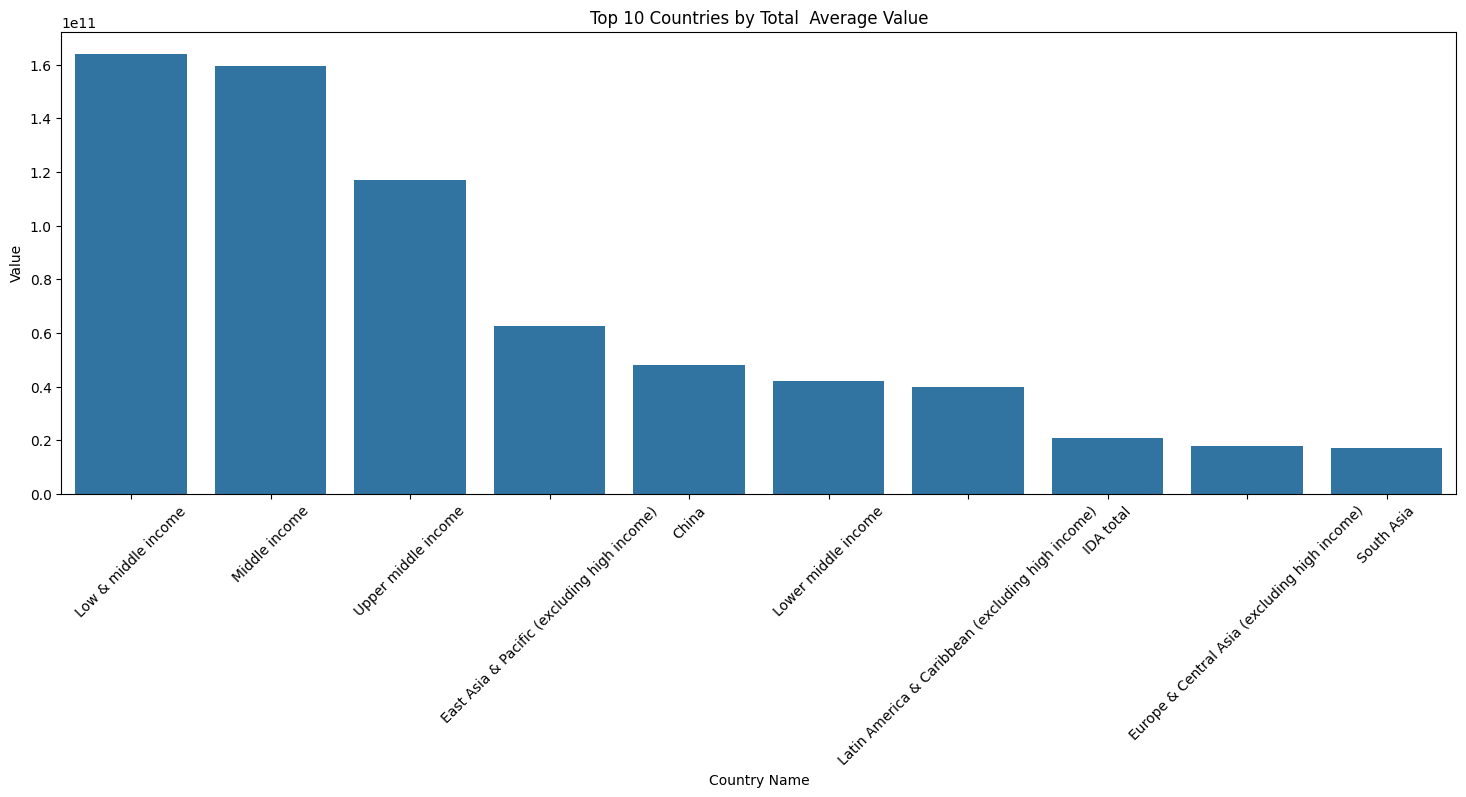

In [11]:
country_sum = (
    all_country_metadata
    .groupby('Country Name', as_index=False)['Value']
    .mean()
    .sort_values('Value', ascending=False)
    .head(10)
)

plt.figure(figsize=(18, 6))

sns.barplot(
    data=country_sum,
    x='Country Name',
    y='Value'
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Total  Average Value")

plt.show()

In [ ]:
all_country_metadata['Country Name'].unique()

In [ ]:
all_country_metadata['Series Name'].nunique() # 576

In [ ]:
all_country_metadata['Series Code'].nunique() #576

In [ ]:
series_metadata.info()

In [ ]:
series_metadata['Indicator Name'].nunique()

In [12]:
import pandas as pd
country_mdata=pd.read_csv('country_metedata.csv')
#country_mdata.isnull().sum()

In [13]:
country_mdata

,Code,Long Name,Income Group,Other groups,Latest population census,Latest household survey,National accounts base year,National accounts reference year,System of National Accounts,SNA price valuation,...,IMF data dissemination standard,Source of most recent Income and expenditure data,Vital registration complete,Latest industrial data,Latest trade data,Latest water withdrawal data,2-alpha code,WB-2 code,Table Name,Short Name
0,AFG,Islamic State of Afghanistan,Low income,HIPC,1979,Multiple Indicator Cluster Survey 2022-2023,2016,2010.0,Country uses the 2008 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Integrated household survey (IHS), 2016/17",Yes,2013.0,2018.0,2000.0,AF,AF,Afghanistan,Afghanistan
1,ALB,Republic of Albania,Upper middle income,HIPC,2023,Demographic and Health Survey 2017 - 2018,Original chained constant price data are resca...,2020.0,Country uses the 2008 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,Living Standards Measurement Study Survey (LSM...,Yes,2013.0,2018.0,2006.0,AL,AL,Albania,Albania
2,DZA,People's Democratic Republic of Algeria,Upper middle income,HIPC,2022,Multiple Indicator Cluster Survey 2018-2019,Original chained constant price data are resca...,2001.0,Country uses the 2008 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Integrated household survey (IHS), 2011",Yes,2010.0,2017.0,2012.0,DZ,DZ,Algeria,Algeria
3,AGO,People's Republic of Angola,Lower middle income,HIPC,2014,Demographic and Health Survey 2015/16,2002,2001.0,Country uses the 1993 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Integrated household survey (IHS), 2008/09",Yes,2002.0,2018.0,2005.0,AO,AO,Angola,Angola
4,ARG,Argentine Republic,Upper middle income,HIPC,2022,Multiple Indicator Cluster Survey 2019-2020,2004,2001.0,Country uses the 2008 System of National Accou...,Value added at basic prices (VAB),...,Special Data Dissemination Standard (SDDS),"Integrated household survey (IHS), 2016",Yes,2002.0,2018.0,2011.0,AR,AR,Argentina,Argentina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,VUT,Republic of Vanuatu,Lower middle income,HIPC,2016,Multiple Indicator Cluster Survey 2007,2006,2010.0,Country uses the 1993 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Integrated household survey (IHS), 2010",Yes,2013.0,2011.0,2005.0,VU,VU,Vanuatu,Vanuatu
130,VNM,Socialist Republic of Viet Nam,Lower middle income,HIPC,2019,Multiple Indicator Cluster Survey 2020-2021,2010,2010.0,Country uses the 1993 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Integrated household survey (IHS), 2016",Yes,2013.0,2017.0,2005.0,VN,VN,Viet Nam,Viet Nam
131,YEM,Republic of Yemen,Low income,HIPC,2004,National Health and Demographic Survey 2013,1990,2010.0,Country uses the 1993 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Expenditure survey/budget survey (ES/BS), 2014",Yes,2012.0,2015.0,2005.0,YE,RY,"Yemen, Rep.","Yemen, Republic of"
132,ZMB,Republic of Zambia,Lower middle income,HIPC,2022,Demographic and Health Survey 2018,2010,2010.0,Country uses the 2008 System of National Accou...,Value added at basic prices (VAB),...,Enhanced General Data Dissemination System (e-...,"Integrated household survey (IHS), 2015",Yes,1994.0,2018.0,2002.0,ZM,ZM,Zambia,Zambia


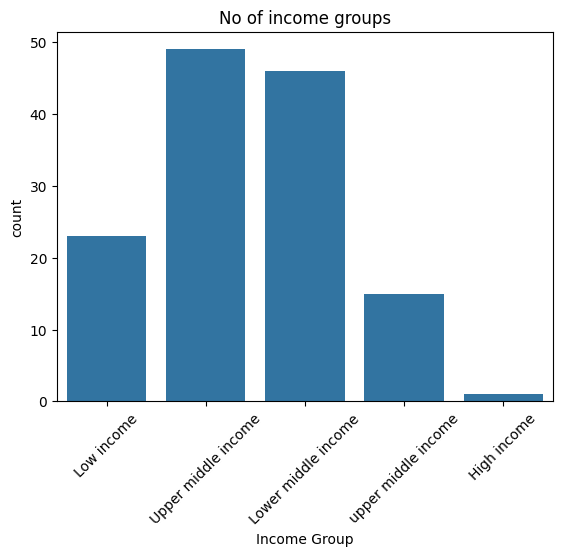

In [14]:
sns.countplot(
    data=country_mdata,
    x='Income Group'
)
plt.xticks(rotation=45)
plt.title("No of income groups")

plt.show()

In [ ]:
country_mdata[country_mdata['Latest population census']=='1987. Enumeration of settled population was in November 1986 and of nomads in February 1987.']

In [15]:
country_mdata.drop(106,inplace=True)
# here i drop the row

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

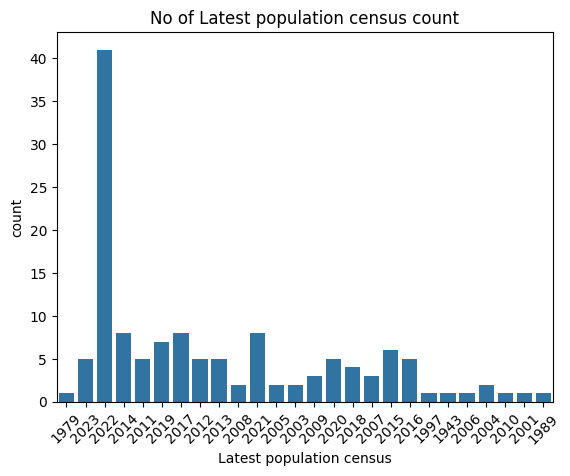

In [16]:
sns.countplot(
    data=country_mdata,
    x='Latest population census'
)
plt.title("No of Latest population census count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
country_mdata['Latest population census'].unique()

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
country_mdata['System of trade'].unique()

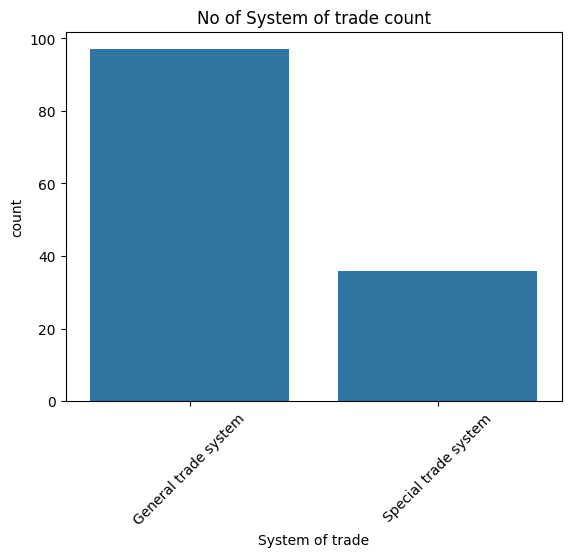

In [21]:
sns.countplot(
    data=country_mdata,
    x='System of trade'
)
plt.title("No of System of trade count")
plt.xticks(rotation=45)


plt.show()

In [ ]:
country_mdata['Balance of Payments Manual in use'].unique()

In [ ]:
sns.countplot(
    data=country_mdata,
    x='Balance of Payments Manual in use'
)
plt.title("No of Balance of Payments Manual in use count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
country_mdata['Latest population census'].unique()

In [ ]:
sns.countplot(
    data=country_mdata,
    x='External debt Reporting status'
)
plt.title("No of 'External debt Reporting status' count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
country_mdata['Latest industrial data'].unique()

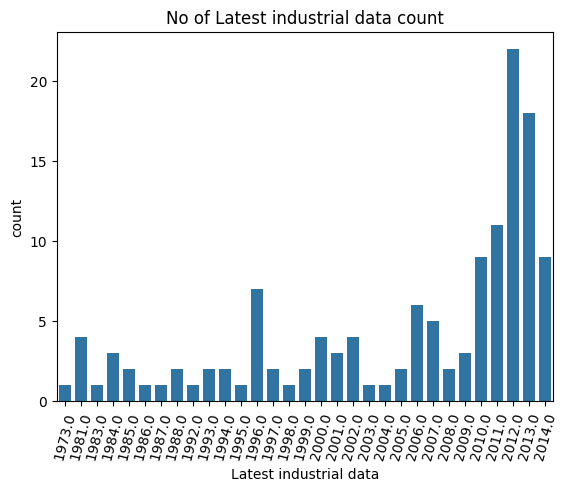

In [17]:
sns.countplot(
    data=country_mdata,
    x='Latest industrial data'
)
plt.title("No of Latest industrial data count")
plt.xticks(rotation=75)
plt.show()

In [ ]:
sns.countplot(
    data=country_mdata,
    x='Latest trade data'
)
plt.title("No of Latest trade data count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
country_mdata['External debt Reporting status'].unique()

In [ ]:
country_mdata['PPP survey years'].unique()

In [19]:
series_metadata=pd.read_csv('series_metadata.csv')
series_metadata.isnull().sum()

Code                  0
Indicator Name        0
Short definition      0
Long definition       0
Source                0
Topic                 0
Dataset               0
Periodicity           0
Aggregation method    0
dtype: int64

In [ ]:
pd.set_option('display.Max_Rows', None)

In [ ]:
series_metadata['Code'].nunique()

In [ ]:
series_metadata['Code'].value_counts()

In [24]:
import pandas as pd
foot_metadata=pd.read_csv('foot_metadata.csv')

In [25]:
foot_metadata

,Unnamed: 0,Type,Country Code,Series Code,Time Code,Description
0,0,FootNote,Afghanistan (AFG),Personal transfers and compensation of employe...,2024 (YR2024),Data on Personal Transfers and Compensation of...
1,1,FootNote,Afghanistan (AFG),Personal transfers and compensation of employe...,2023 (YR2023),Source: United Nations Conference on Trade and...
2,2,FootNote,Afghanistan (AFG),Personal transfers and compensation of employe...,2021 (YR2021),Source: United Nations Conference on Trade and...
3,3,FootNote,Afghanistan (AFG),Personal transfers and compensation of employe...,2022 (YR2022),Source: United Nations Conference on Trade and...
4,4,FootNote,Afghanistan (AFG),"Foreign direct investment, net inflows in repo...",2021 (YR2021),Source: United Nations Conference on Trade and...
...,...,...,...,...,...,...
2668,2668,FootNote,Zimbabwe (ZWE),"Foreign direct investment, net inflows in repo...",1974 (YR1974),Source: United Nations Conference on Trade and...
2669,2669,FootNote,Zimbabwe (ZWE),"Foreign direct investment, net inflows in repo...",1970 (YR1970),Source: United Nations Conference on Trade and...
2670,2670,FootNote,Zimbabwe (ZWE),"Foreign direct investment, net inflows in repo...",1973 (YR1973),Source: United Nations Conference on Trade and...
2671,2671,FootNote,Zimbabwe (ZWE),"Foreign direct investment, net inflows in repo...",1971 (YR1971),Source: United Nations Conference on Trade and...


In [ ]:
import pandas as pd
import psycopg2  as pg
from sqlalchemy import create_engine
host = "localhost"
port = "5432"  # Default port for PostgreSQL
database = "International_debt_analysis"
username = "postgres"
password = "lavi"
engine_string = f"postgresql://{username}:{password}@{host}:{port}/{database}"
connection=create_engine(engine_string)
df=pd.read_csv('all_country_metadata.csv')
df.to_sql('all_country_metadata',
          con=engine_string,
          if_exists='replace',
          index=False)



In [ ]:
import pandas as pd
import psycopg2  as pg
from sqlalchemy import create_engine
host = "localhost"
port = "5432"  # Default port for PostgreSQL
database = "International_debt_analysis"
username = "postgres"
password = "lavi"
engine_string = f"postgresql://{username}:{password}@{host}:{port}/{database}"
connection=create_engine(engine_string)
df=pd.read_csv('country_metedata.csv')
df.to_sql('country_metadata',
          con=engine_string,
          if_exists='replace',
          index=False)

In [ ]:
host = "localhost"
port = "5432"  # Default port for PostgreSQL
database = "International_debt_analysis"
username = "postgres"
password = "lavi"
engine_string = f"postgresql://{username}:{password}@{host}:{port}/{database}"
connection=create_engine(engine_string)
df=pd.read_csv('series_metadata.csv')
df.to_sql('series_metadata',
          con=engine_string,
          if_exists='replace',
          index=False)

In [ ]:
host = "localhost"
port = "5432"  # Default port for PostgreSQL
database = "International_debt_analysis"
username = "postgres"
password = "lavi"
engine_string = f"postgresql://{username}:{password}@{host}:{port}/{database}"
connection=create_engine(engine_string)
df=pd.read_csv('foot_metadata.csv')
df.to_sql('foot_metadata',
          con=engine_string,
          if_exists='replace',
          index=False)